## what does regression_metrics actually means ?? 

When your model predicts, it makes errors. Regression metrics are just different ways of summarizing how big those errors are.

### types of regression_metrics ?? 

1) MAE
2) MSE
3) RMSE
4) r2 score 
5) adjusted r2 score 

to again review this topic as this can be asked - [regression_metrics](https://youtu.be/Ti7c-Hz7GSM?si=wXlubPFh1vyJuvr-)

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head(2)

,cgpa,package
0,6.89,3.26
1,5.12,1.98


by visualising the data we can clearly see it shows the linear tendency 

Text(0, 0.5, 'palcement')

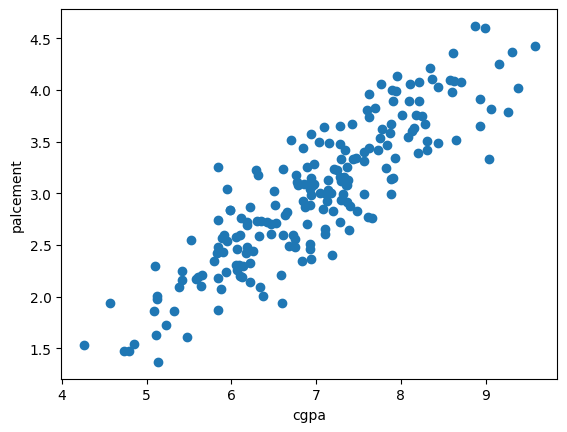

In [4]:
plt.scatter(df["cgpa"],df["package"])
plt.xlabel("cgpa")
plt.ylabel("palcement")

"now performing the linear_regressiona"

In [5]:
lr = LinearRegression()

In [6]:
x_train , x_test , y_train , y_test = train_test_split(df[["cgpa"]],df[["package"]],random_state=42 , test_size=0.2)

In [7]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
x_result = lr.predict(x_test)
lr.score(x_test,y_test)

0.7730984312051673

In [9]:
print("predicted values ", x_result)

predicted values  [[2.78031348]
 [3.13635249]
 [3.1995207 ]
 [2.38981908]
 [3.52684689]
 [3.76803461]
 [3.16506531]
 [2.54486832]
 [3.17655044]
 [3.4923915 ]
 [1.90744364]
 [2.34962112]
 [3.6876387 ]
 [2.75734322]
 [3.47516381]
 [3.04447145]
 [2.32665086]
 [3.20526327]
 [2.17734418]
 [3.314372  ]
 [2.45298729]
 [2.90090734]
 [3.32011456]
 [2.87219451]
 [3.33734226]
 [2.19457187]
 [1.41932564]
 [2.7114027 ]
 [3.18229301]
 [2.32665086]
 [3.74506435]
 [2.95833298]
 [3.68189614]
 [2.97556068]
 [2.59080884]
 [3.34882738]
 [2.47595755]
 [3.07318428]
 [4.17575671]
 [2.95833298]]


## now performing the regression_metrics

### MSE


In [11]:
from sklearn.metrics import mean_squared_error as mse 

In [12]:
mse_result = mse(y_true=y_test,y_pred=x_result)
print(mse_result)

0.08417638361329656


### RMSE

In [14]:
from sklearn.metrics import root_mean_squared_error as rmse

rmse_result = rmse(y_true=y_test,y_pred=x_result)
print(rmse_result)

0.2901316659954521


In [20]:
## also checking if we find the root of mse , would it be same as rmse
result = np.sqrt(mse_result)
print(result)

0.2901316659954521


### MAE

In [15]:
from sklearn.metrics import mean_absolute_error as mae

In [16]:
mae_result = mae(y_true=y_test,y_pred=x_result)
print(mae_result)

0.23150985393278373


### R2 score 

In [18]:
from sklearn.metrics import r2_score as r2 

In [19]:
r2_score = r2(y_true=y_test,y_pred=x_result)
print(r2_score)

0.7730984312051673


### what all this means ?? 
R² = 0.77
Your model explains 77% of the variation in package based on CGPA alone. That's actually pretty good for a simple linear regression with just one feature!

RMSE = 0.29 & MAE = 0.23
These are in the same unit as your package column. So the question is — what unit is your package in?

If package is in lakhs → your predictions are off by ~0.23 to 0.29 lakhs — that's excellent!
If package is in crores → off by ~0.23 to 0.29 crores — still reasonable


RMSE (0.29) > MAE (0.23) — this is normal and expected. The gap between them tells you:

there are a few students where your model made bigger mistakes, but most predictions are pretty close

If RMSE was way higher than MAE, it would mean you have significant outliers causing big errors.

Bottom line — your model is decent! 🎉
The only thing that could make it better is adding more features like:

Internships
Projects
College tier

Because right now you're predicting package from CGPA alone, and 77% is solid for that!